In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import dask.dataframe as dd
from urllib.parse import urlparse, urlunparse
from urllib.parse import quote, unquote

def normalize_url(url):
    parsed = urlparse(url)
    # Remove 'www.' if it exists in the netloc
    netloc = parsed.netloc.lower().strip()
    if netloc.startswith("www."):
        netloc = netloc[4:]  # Strip the 'www.' prefix

    normalized = urlunparse(parsed._replace(
        # scheme=parsed.scheme.lower(),
        scheme="http",
        netloc=netloc,
        path=parsed.path.strip('/')
    ))
    return normalized

def strip_url_params(url):
    parsed = urlparse(url)
    stripped = urlunparse(parsed._replace(query='', fragment=''))
    return stripped

def encode_url(url):
    return quote(unquote(url), safe=':/?=&')

/rhome/sawale/indus_traning/mlm-fine-tuning/.venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [4]:
df = pd.read_parquet("../data/parsed_sde_init_check")
urls_df = pd.read_json('../data/candidate_urls.zip')


In [7]:
df.shape, df.drop_duplicates().shape

((1660774, 6), (1660748, 6))

In [5]:
dx = df.drop_duplicates(subset=['url'])

dx.head()

,url,first_field,second_field,third_field,fourth_field,text
__null_dask_index__,,,,,,
0,https://www.earthsciweek.org/,Earth Science Week,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Earth Science Week,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...
1,https://www.earthsciweek.org/contests,Earth Science Week Contests,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Earth Science Week Contests,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...
2,https://www.earthsciweek.org/get-involved,Get Involved with Earth Science Week,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Get Involved with Earth Science Week,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...
3,https://www.earthsciweek.org/resources,Earth Science Week Resources,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Earth Science Week Resources,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...
4,https://www.earthsciweek.org/support,Support Earth Science Week,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Support Earth Science Week,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...


In [9]:
urls_df.shape, urls_df.drop_duplicates().shape, urls_df.drop_duplicates(subset=['url']).shape

((510292, 6), (510292, 6), (510292, 6))

In [13]:
df['normalized_url'] = df['url'].apply(normalize_url)
urls_df['normalized_url'] = urls_df['url'].apply(normalize_url)

# df['normalized_url'] = df['normalized_url'].apply(strip_url_params)
# urls_df['normalized_url'] = urls_df['normalized_url'].apply(strip_url_params)

# df['normalized_url'] = df['normalized_url'].apply(encode_url)
# urls_df['normalized_url'] = urls_df['normalized_url'].apply(encode_url)

In [14]:
result = df.merge(urls_df, on='normalized_url', how='inner')

In [15]:
result.shape

(122104, 13)

In [41]:
result["normalized_url"].nunique(), result["url"].nunique(), 

KeyError: 'url'

In [32]:
df["url"].nunique(), urls_df["url"].nunique(), df["normalized_url"].nunique(), urls_df["normalized_url"].nunique()

(1653619, 510292, 967074, 271202)

In [7]:
urls_df["url"].apply(lambda x: x.split("/")[0]).value_counts()

url
https:    508832
http:       1460
Name: count, dtype: int64

In [21]:
df[df["url"] == ""]

,url,first_field,second_field,third_field,fourth_field,text,normalized_url
__null_dask_index__,,,,,,,
3732,,s Halo Finder https://ascl.net/code/cs/Knol...,"ASCL.net - Credit Search for 'Knollmann, ...",/scrapers/astrophysics_source_code_library/,['/Astrophysics/Astrophysics Source Code Libra...,,http://
18457,,"also, a bit about citing software - ASCL.net ...",Wenskovitch_EWASS2017CompSciPerspective.pdf,/scrapers/astrophysics_source_code_library/,['/Astrophysics/Astrophysics Source Code Libra...,,http://
22083,,Detector Background https://asd.gsfc.nasa....,NAME ATLAS - NUMBERED NAMES,/scrapers/astrophysics_science_division_asd_co...,['/Astrophysics/Astrophysics Science Division ...,,http://
43675,,Prior to 1500 C.E. https://spdf.gsfc.nasa....,Examples from GE-11C: New England Auroral Obs.,/scrapers/Space_Physics_Data_Facility/,['/Heliophysics/Space Physics Data Facility (S...,,http://
44440,,Prior to 1500 C.E. https://spdf.gsfc.nasa....,Index of /pub/data/aaa_balloons/barrel/l2,/scrapers/Space_Physics_Data_Facility/,['/Heliophysics/Space Physics Data Facility (S...,,http://
...,...,...,...,...,...,...,...
1489402,,how can I remove them? - CIAO 4.11 ChIPS v1 ...,FAQ: How do I select an object (change currenc...,/scrapers/chandra_x_ray_center_cxc/,['/Astrophysics/Chandra X-Ray Center (CXC)/'],,http://
1545086,,https://l0dup05.larc.nasa.gov/cgi-bin/DUE/...,MISR Processing Status: Level 3 New Aerosol Joint,/scrapers/asdc_misr/,['/Earth Science/ASDC - MISR/'],,http://
1549904,,"Deadline: April 30, 2008 https://lpdaac.us...",LP DAAC - Community Outreach Workshop on MODIS...,/scrapers/land_processes_distributed_active_ar...,['/Earth Science/Land Processes Distributed Ac...,,http://


In [ ]:

dx = pd.read_parquet('../data/parsed_sde_init_check_with_title.parquet')

In [23]:
dx.shape

(121157, 11)

In [24]:
dx.head()

,url,first_field,second_field,third_field,fourth_field,text,collection__config_folder,generated_title,scraped_title,division_display,document_type_display
__null_dask_index__,,,,,,,,,,,
0,https://www.earthsciweek.org/,Earth Science Week,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Earth Science Week,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...,earth_science_week,,Earth Science Week,,
1,https://www.earthsciweek.org/contests,Earth Science Week Contests,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Earth Science Week Contests,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...,earth_science_week,,Earth Science Week Contests,,
2,https://www.earthsciweek.org/get-involved,Get Involved with Earth Science Week,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Get Involved with Earth Science Week,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...,earth_science_week,,Get Involved with Earth Science Week,,
3,https://www.earthsciweek.org/resources,Earth Science Week Resources,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Earth Science Week Resources,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...,earth_science_week,,Earth Science Week Resources,,
4,https://www.earthsciweek.org/support,Support Earth Science Week,/scrapers/earth_science_week/,/Earth Science/Earth Science Week/,Support Earth Science Week,TOOLKIT CONTESTS WEBINARS GET INVOLVED RE...,earth_science_week,,Support Earth Science Week,,


In [7]:
df = dd.read_parquet('../data/parsed_sde_init_check_with_title.parquet')

df.compute().shape

(121157, 11)

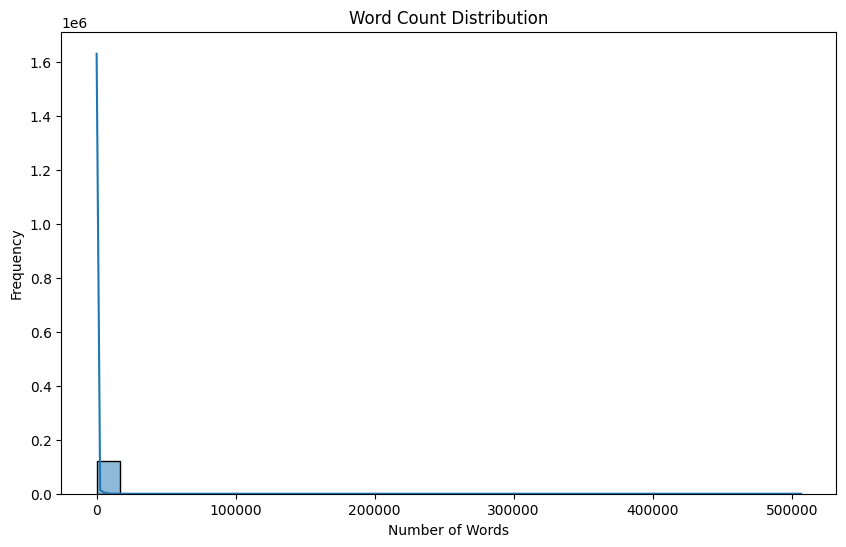

In [9]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your Dask dataframe (adjust file path as necessary)
df = dd.read_parquet('../data/parsed_sde_init_check_with_title.parquet')

# Count the number of words in each row using Dask
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()), meta=('x', 'int64'))

# Compute the word counts and convert to pandas for plotting
word_counts = df['word_count'].compute()

# Create the distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(word_counts, kde=True, bins=30)

# Set plot labels and title
plt.title('Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Show plot
plt.show()


In [17]:
word_counts.shape

(121157,)

In [16]:
word_counts.min(), word_counts.quantile(0.25), word_counts.median(), word_counts.quantile(0.75),word_counts.max(), word_counts.mean()

(np.int64(0),
 np.float64(98.0),
 np.float64(308.0),
 np.float64(586.0),
 np.int64(506808),
 np.float64(486.2965573594592))

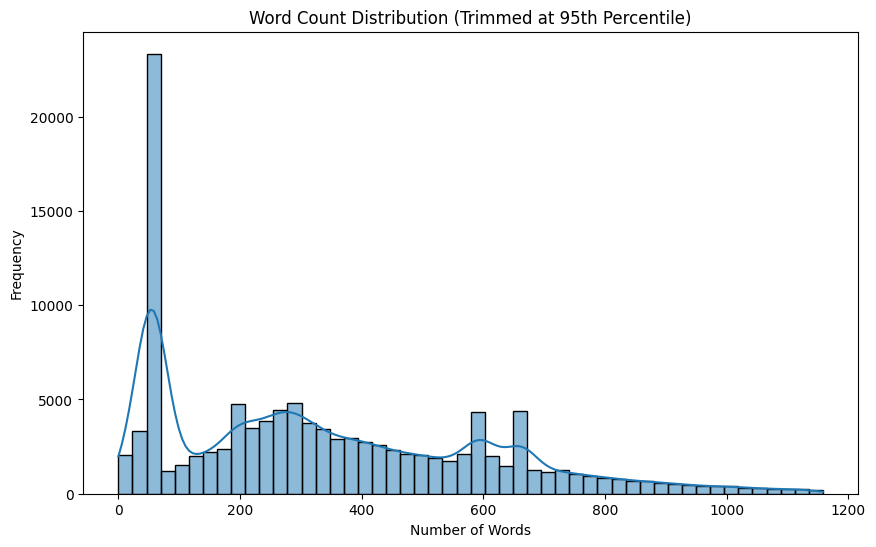

In [28]:
percentile_95 = word_counts.quantile(0.95)

# Filter out word counts greater than the 95th percentile
trimmed_word_counts = word_counts[word_counts <= percentile_95]

# Create the distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(trimmed_word_counts, kde=True, bins=50)

# Set plot labels and title
plt.title('Word Count Distribution (Trimmed at 95th Percentile)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Show plot
plt.show()